In [1]:
# Install Hugging Face transformers library.
%pip install torch==1.13.1 torchvision==0.14.1 numpy==1.24.0 transformers==4.30.0 
%pip install opencv-python==4.7.0.72
%pip install pillow-heif

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
from tqdm.auto import tqdm
import cv2
from urllib.request import urlretrieve
from zipfile import ZipFile
from craft_text_detector import Craft

import numpy as np
import matplotlib.pyplot as plt
import torch
import os
import glob
from craft_text_detector import Craft
from pillow_heif import register_heif_opener
register_heif_opener()



/Users/tejasvi/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/tejasvi/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import craft_text_detector.predict as predict
print(predict.__file__)

/Users/tejasvi/Library/Python/3.9/lib/python/site-packages/craft_text_detector/predict.py


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Download Data

In [5]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assets....", end="")

    # Downloading zip file using urllib package.
    urlretrieve(url, save_path)

    try:
        # Extracting zip file using the zipfile package.
        with ZipFile(save_path) as z:
            # Extract ZIP file contents in the same directory.
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)

In [6]:
URL = r"https://www.dropbox.com/scl/fi/jz74me0vc118akmv5nuzy/images.zip?rlkey=54flzvhh9xxh45czb1c8n3fp3&dl=1"
asset_zip_path = os.path.join(os.getcwd(), "images.zip")
# Download if assest ZIP does not exists.
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)


The `read_image()` function will take an image path as input, read the image, visualize it, and return the image.

In [7]:
def read_image(image_path):
    """
    :param image_path: String, path to the input image.

    Returns:
        image: PIL Image.
    """
    image = Image.open(image_path).convert('RGB')
    return image

In [8]:
# instantiate CRAFT once
craft = Craft(output_dir=None, crop_type="box", cuda=False)

/Users/tejasvi/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:252: UserWarning: Accessing the model URLs via the internal dictionary of the module is deprecated since 0.13 and may be removed in the future. Please access them via the appropriate Weights Enum instead.
  warnings.warn(
/Users/tejasvi/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/tejasvi/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [9]:
def sort_boxes(boxes, line_threshold=20):
    # sort by y first
    boxes = sorted(boxes, key=lambda box: box[0][1])
    
    lines = []
    current_line = [boxes[0]]
    
    for box in boxes[1:]:
        # if y is close to current line, it's on the same line
        if abs(box[0][1] - current_line[0][0][1]) < line_threshold:
            current_line.append(box)
        else:
            # sort current line left to right, start new line
            lines.append(sorted(current_line, key=lambda box: box[0][0]))
            current_line = [box]
    lines.append(sorted(current_line, key=lambda box: box[0][0]))
    
    # flatten back to list of boxes
    return [box for line in lines for box in line]

The following `ocr()` functions performs Optical Character Recognition on a cropped image of text.

It takes the image in PIL format, passes it through the OCR processor and model and returns the generated text in String format.

In [10]:
def ocr(image, image_path, processor, model):
    image = read_image(image_path)  # PIL handles all formats including HEIC
    image_np = np.array(image)
    result = craft.detect_text(image_np)
    boxes = result["boxes"]
    texts = []
     # sort boxes top-to-bottom, then left-to-right
    boxes = sort_boxes(boxes)

    for box in boxes:
        crop = image.crop([box[0][0], box[0][1], box[2][0], box[2][1]])
        pixel_values = processor(crop, return_tensors="pt").pixel_values
        with torch.no_grad():
            generated_ids = model.generate(pixel_values)
        text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
        texts.append(text)
    return texts

In [11]:
def eval_new_data(data_path=None, num_samples=None, model=None):
    image_paths = glob.glob(data_path)
    for i, image_path in tqdm(enumerate(image_paths), total=len(image_paths)):
        if i == num_samples:
            break
        image = read_image(image_path)
        text = ocr(image, image_path, processor, model)
        plt.figure(figsize=(7, 4))
        plt.imshow(image)
        plt.title(text)
        plt.axis('off')
        plt.show()

## Printed Text

In [12]:
processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-printed')
model = VisionEncoderDecoderModel.from_pretrained(
    'microsoft/trocr-base-printed'
).to(device)

/Users/tejasvi/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-printed and are newly initialized: ['decoder.output_projection.weight', 'encoder.pooler.dense.weight', 'encoder.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/2 [00:00<?, ?it/s]/Users/tejasvi/Library/Python/3.9/lib/python/site-packages/transformers/generation/utils.py:1353: UserWarning: Using `max_length`'s default (20) to control the generation length. This behaviour is deprecated and will be removed from the config in v5 of Transformers -- we recommend using `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


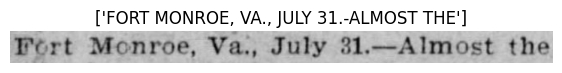

 50%|█████     | 1/2 [00:02<00:02,  2.83s/it]

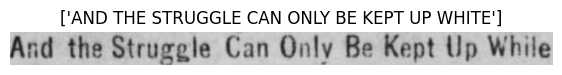

100%|██████████| 2/2 [00:05<00:00,  2.71s/it]


In [13]:
eval_new_data(
    data_path=os.path.join('images', 'newspaper', '*'),
    model=model
)

## Handwritten Text

In [14]:
processor = TrOCRProcessor.from_pretrained('microsoft/trocr-large-handwritten')
model = VisionEncoderDecoderModel.from_pretrained(
    'microsoft/trocr-large-handwritten'
).to(device)

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-large-handwritten and are newly initialized: ['encoder.pooler.dense.weight', 'encoder.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/4 [00:00<?, ?it/s]

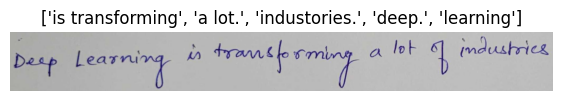

 25%|██▌       | 1/4 [00:07<00:21,  7.24s/it]

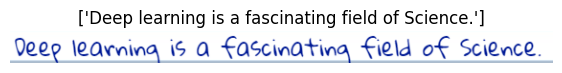

 50%|█████     | 2/4 [00:09<00:09,  4.57s/it]

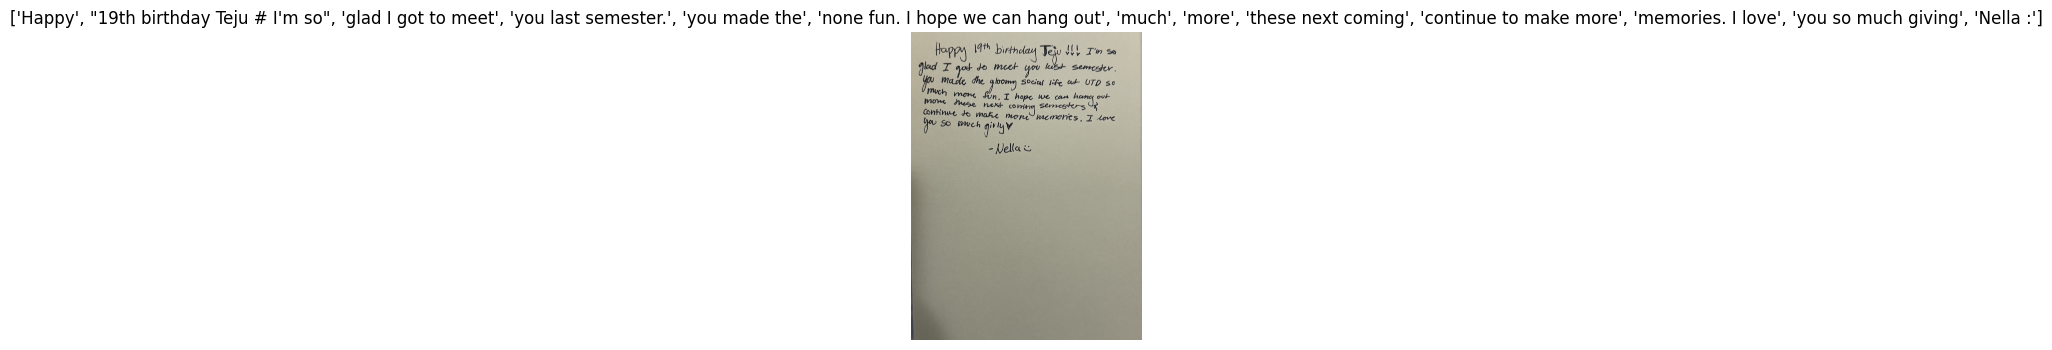

 75%|███████▌  | 3/4 [00:36<00:14, 14.40s/it]

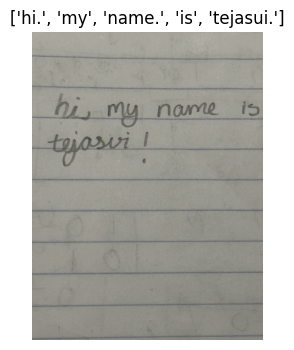

100%|██████████| 4/4 [00:48<00:00, 12.11s/it]


In [15]:
eval_new_data( 
    data_path=os.path.join('images', 'handwritten', '*'), 
    model=model 
    )